# Data

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor, Normalize, Compose
import numpy as np
from torch.utils.data import random_split
torch.manual_seed(42) 
from torch.utils.data import DataLoader
from medmnist import ChestMNIST

## Normalisation

In [13]:
from torch.utils.data import DataLoader

dataset = ChestMNIST(split='train', transform=transforms.ToTensor(), download=False)
loader = DataLoader(dataset, batch_size=64, shuffle=False)

mean = 0.
std = 0.
total_pixels = 0

for images, _ in loader:
    pixels = images.numel() #number of elements in the batch
    mean += images.sum() #mean numeratot
    std += (images ** 2).sum()
    total_pixels += pixels

mean /= total_pixels
std = torch.sqrt(std / total_pixels - mean ** 2)

print(f'Mean: {mean.item() :.4f}, Std: {std.item() :.4f}')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std])
])

train_dataset_org = ChestMNIST(split='train', transform=transform, download=False)
test_dataset_org = ChestMNIST(split='test', transform=transform, download=False)
val_dataset_org = ChestMNIST(split='val', transform=transform, download=False)

Mean: 0.4936, Std: 0.2380


## Basic data info

In [14]:
print(f'Img shape: {train_dataset_org[0][0].shape}')
print(f'Lab shape: {train_dataset_org[0][1].shape}')

Img shape: torch.Size([1, 28, 28])
Lab shape: (14,)


In [15]:
train_dataset_org.info['label'].values()

dict_values(['atelectasis', 'cardiomegaly', 'effusion', 'infiltration', 'mass', 'nodule', 'pneumonia', 'pneumothorax', 'consolidation', 'edema', 'emphysema', 'fibrosis', 'pleural', 'hernia'])

In [23]:
train_dataset_org[0]

(tensor([[[-1.0689, -1.9256, -1.8597, -1.8762, -1.8762, -1.8762, -1.8597,
           -1.7609, -1.5632, -1.3325, -0.9206, -0.3768, -0.0473,  0.2822,
            0.5953,  0.5953,  0.5953,  0.2822, -0.1462, -0.4757, -1.0194,
           -1.4149, -1.7279, -1.8597, -1.8927, -1.8597, -1.7279, -1.7114],
          [-1.1842, -1.9586, -1.9092, -1.8762, -1.7444, -1.5137, -1.2830,
           -1.0524, -0.8547, -0.7064, -0.5581, -0.1626,  0.0845,  0.3152,
            0.6118,  0.5953,  0.6282,  0.3646,  0.0845, -0.1791, -0.5416,
           -0.7558, -1.0029, -1.3490, -1.6785, -1.7279, -1.5961, -1.5137],
          [-1.0194, -1.6950, -1.3160, -1.1018, -0.8876, -0.6405, -0.4592,
           -0.3439, -0.3439, -0.5086, -0.6405, -0.3768,  0.0021,  0.3481,
            0.6612,  0.5788,  0.6612,  0.4305,  0.0351, -0.3109, -0.5910,
           -0.5746, -0.4757, -0.6569, -0.9865, -1.3325, -1.6291, -1.8268],
          [-0.2615, -0.9865, -0.3274, -0.1791, -0.0967,  0.0351,  0.0680,
            0.0845, -0.4263, -0.970

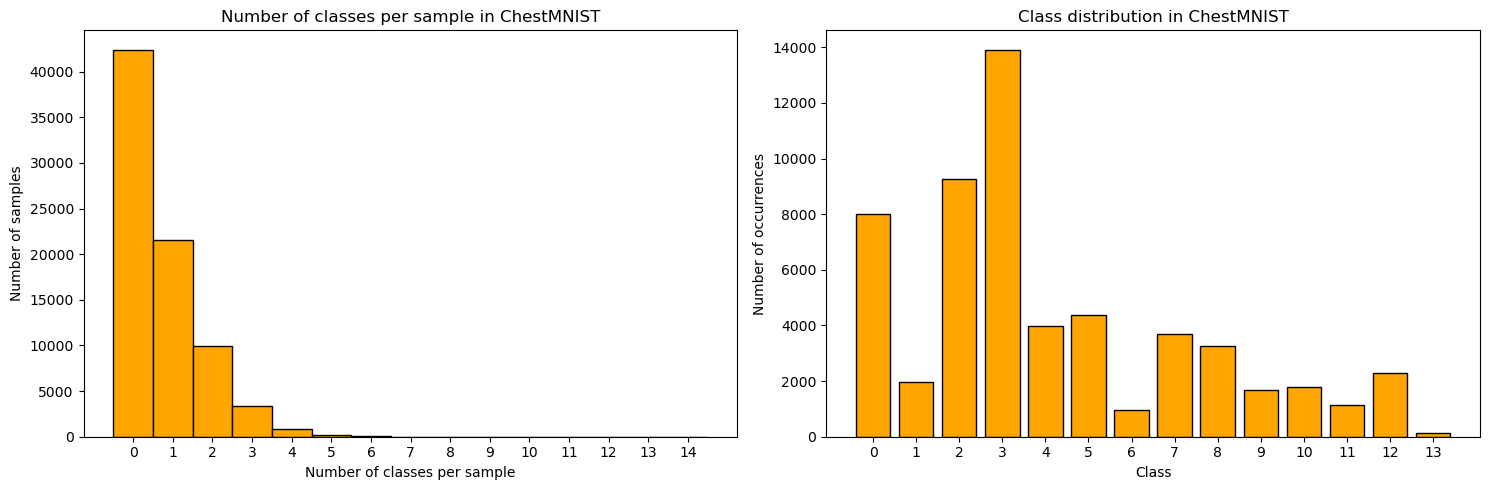

In [16]:
#Get all labels in the training set
all_labels = np.array([label for _, label in train_dataset_org])

#num of classes per sample
classes_per_sample = all_labels.sum(axis=1)

#Class distribution
class_counts = all_labels.sum(axis=0)

#plots
fig, axes = plt.subplots(1, 2, figsize=(15,5))

#num of classes
axes[0].hist(classes_per_sample, bins=np.arange(0, 16)-0.5, color='orange',edgecolor='black')
axes[0].set_xticks(range(0, 15))
axes[0].set_xlabel("Number of classes per sample")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Number of classes per sample in ChestMNIST")

#class distribution
axes[1].bar(range(14), class_counts, color='orange',edgecolor='black')
axes[1].set_xticks(range(14))
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of occurrences")
axes[1].set_title("Class distribution in ChestMNIST")

plt.tight_layout()
plt.show()

## Rare classes filtration

In [17]:
import torch
import numpy as np

class FilterRareClassesDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, min_count=2000, keep_classes_idx=None):
        """
        If keep_classes_idx is None -> compute based on the dataset (e.g., train)
        If provided -> use the same class indices (e.g., for val/test)

        False healthy samples (no disease after filtering out rare classes) are deleted from the dataset.
        """
        self.dataset = dataset

        if keep_classes_idx is None:
            #number of samples per class 
            all_labels_np = np.stack([dataset[i][1] for i in range(len(dataset))])
            class_counts = all_labels_np.sum(axis=0)

            # keep classes with >= min_count samples
            self.keep_classes_idx = np.where(class_counts >= min_count)[0]
            label_dict = dataset.info['label']
            # map class indices to names
            kept_names = [label_dict[str(idx)] for idx in self.keep_classes_idx]

            print(f"Classes after filtration: {self.keep_classes_idx}, {kept_names}, number: {len(self.keep_classes_idx)}")

        else:
            self.keep_classes_idx = keep_classes_idx

        #indexes of non-false-healthy samples
        self.valid_indices = []
        for i in range(len(self.dataset)):
            _, label = self.dataset[i]

            if isinstance(label, np.ndarray):
                original_has_disease = label.sum() > 0
                filtered_label = label[self.keep_classes_idx]
                filtered_has_disease = filtered_label.sum() > 0
            else:  # torch.Tensor
                original_has_disease = label.sum().item() > 0
                filtered_label = label[self.keep_classes_idx]
                filtered_has_disease = filtered_label.sum().item() > 0

            #delete false healthy samples: was sick -> healthy after filtering
            if not (original_has_disease and not filtered_has_disease):
                self.valid_indices.append(i)

        print(
            f"Deleted {len(self.dataset) - len(self.valid_indices)} false healthy samples, num of samples after filtration: {len(self.valid_indices)}"
        )

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        real_idx = self.valid_indices[idx]
        img, label = self.dataset[real_idx]

        # filter label to keep only the filtered classes
        if isinstance(label, np.ndarray):
            label = label[self.keep_classes_idx]
        elif torch.is_tensor(label):
            label = label[self.keep_classes_idx]

        return img, label

#filter train
train_dataset = FilterRareClassesDataset(train_dataset_org, min_count=2000)

#filter text/val based on train kept classes
val_dataset  = FilterRareClassesDataset(val_dataset_org, keep_classes_idx=train_dataset.keep_classes_idx)
test_dataset = FilterRareClassesDataset(test_dataset_org, keep_classes_idx=train_dataset.keep_classes_idx)

num_classes = len(train_dataset.keep_classes_idx)

Classes after filtration: [ 0  2  3  4  5  7  8 12], ['atelectasis', 'effusion', 'infiltration', 'mass', 'nodule', 'pneumothorax', 'consolidation', 'pleural'], number: 8
Deleted 2772 false healthy samples, num of samples after filtration: 75696
Deleted 375 false healthy samples, num of samples after filtration: 10844
Deleted 811 false healthy samples, num of samples after filtration: 21622


## Save datasets

In [18]:
torch.save({
    'train': train_dataset,
    'val': val_dataset,
    'test': test_dataset
}, 'datasets_all.pt')

# CNN

In [19]:
test_epochs = 20

In [20]:
checkpoint = torch.load('datasets_all.pt')

train_dataset = checkpoint['train']
val_dataset = checkpoint['val']
test_dataset = checkpoint['test']

## Pos-weight 

In [21]:
import torch
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
num_classes =  len(train_dataset.keep_classes_idx)

#calculate pos_weight (prevents the model from always predicting the negative class)
all_labels_np = np.stack([train_dataset[i][1] for i in range(len(train_dataset))])
all_labels = torch.from_numpy(all_labels_np).float()
pos_counts = all_labels.sum(dim=0)
neg_counts = all_labels.size(0) - pos_counts
pos_weight = neg_counts / (pos_counts + 1e-6)
pos_weight = pos_weight.to(device) #weights for each class

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(pos_weight)

tensor([ 8.4667,  7.1736,  4.4403, 17.9809, 16.3019, 19.4308, 22.1983, 32.2146])


## Train loop

In [22]:
import os
save_dir_cnn = "models/CNN" 
os.makedirs(save_dir_cnn, exist_ok=True) 

In [ ]:
def train(model, model_name, num_epochs=5, learning_rate=0.001, batch_size=100, patience=5):
    train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    train_f1_micro, train_f1_macro = [], []
    val_f1_micro, val_f1_macro = [], []
    
    best_val_f1 = 0.0
    epochs_no_improve = 0

    best_epoch = -1
    best_model_path = os.path.join(save_dir_cnn, model_name + '.pth')

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        all_pred_train, all_labels_train = [], []

        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = torch.from_numpy(labels).float().to(device) if isinstance(labels, np.ndarray) else labels.float().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            predicted = (torch.sigmoid(outputs) > 0.5).int()
            all_pred_train.append(predicted.cpu())
            all_labels_train.append(labels.cpu())

        all_pred_train = torch.cat(all_pred_train, dim=0).numpy()
        all_labels_train = torch.cat(all_labels_train, dim=0).numpy()

        f1_micro = f1_score(all_labels_train, all_pred_train, average='micro', zero_division=0)
        f1_macro = f1_score(all_labels_train, all_pred_train, average='macro', zero_division=0)

        train_losses.append(running_loss / len(train_loader))
        train_f1_micro.append(f1_micro)
        train_f1_macro.append(f1_macro)

        model.eval()
        all_pred_val, all_labels_val = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = torch.from_numpy(labels).float().to(device) if isinstance(labels, np.ndarray) else labels.float().to(device)
                outputs = model(images)
                predicted = (torch.sigmoid(outputs) > 0.5).int()
                all_pred_val.append(predicted.cpu())
                all_labels_val.append(labels.cpu())

        all_pred_val = torch.cat(all_pred_val, dim=0).numpy()
        all_labels_val = torch.cat(all_labels_val, dim=0).numpy()

        f1_micro_val = f1_score(all_labels_val, all_pred_val, average='micro', zero_division=0)
        f1_macro_val = f1_score(all_labels_val, all_pred_val, average='macro', zero_division=0)

        val_f1_micro.append(f1_micro_val)
        val_f1_macro.append(f1_macro_val)

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {train_losses[-1]:.4f} "
              f"| TRAIN F1 micro: {f1_micro:.4f}, macro: {f1_macro:.4f} "
              f"| VAL F1 micro: {f1_micro_val:.4f}, macro: {f1_macro_val:.4f}")

        # early stopping & save best model
        if f1_micro_val > best_val_f1:
            best_val_f1 = f1_micro_val
            best_epoch = epoch + 1
            torch.save(model.state_dict(), best_model_path)
    
            epochs_no_improve = 0

        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # testing
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
    all_pred_test, all_labels_test = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = torch.from_numpy(labels).float().to(device) if isinstance(labels, np.ndarray) else labels.float().to(device)
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > 0.5).int()
            all_pred_test.append(predicted.cpu())
            all_labels_test.append(labels.cpu())

    all_pred_test = torch.cat(all_pred_test, dim=0).numpy()
    all_labels_test = torch.cat(all_labels_test, dim=0).numpy()
    test_f1_micro = f1_score(all_labels_test, all_pred_test, average='micro', zero_division=0)
    test_f1_macro = f1_score(all_labels_test, all_pred_test, average='macro', zero_division=0)

    test_accuracy = (all_labels_test == all_pred_test).mean() # element-wise accuracy

    print(
        f"\nBest model from epoch {best_epoch} | "
        f"VAL F1 micro: {best_val_f1:.4f}\n"
        f"TEST F1 micro: {test_f1_micro:.4f}, macro: {test_f1_macro:.4f} | "
        f"TEST accuracy: {test_accuracy:.4f}"
    )

    # plots
    epochs_range = range(1, len(train_losses) + 1)
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    axs[0].plot(epochs_range, train_f1_micro, marker='o', label='F1 Micro', color='green')
    axs[0].plot(epochs_range, train_f1_macro, marker='o', label='F1 Macro', color='orange')
    axs[0].set_title('Train F1 Score')
    axs[0].legend(); axs[0].grid(True)
    axs[1].plot(epochs_range, val_f1_micro, marker='o', label='F1 Micro', color='green')
    axs[1].plot(epochs_range, val_f1_macro, marker='o', label='F1 Macro', color='orange')
    axs[1].set_title('Validation F1 Score')
    axs[1].legend(); axs[1].grid(True)
    axs[2].plot(epochs_range, train_losses, marker='o', color='blue')
    axs[2].set_title('Training Loss')
    axs[2].grid(True)
    plt.tight_layout()
    plt.show()

## CNN1: Basic CNN

In [86]:
#two-layer CNN (convolutional neural network)

class CNN_1(nn.Module):
    def __init__(self, num_classes):
        super(CNN_1, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=2), 
            nn.BatchNorm2d(16),     # Batch normalization: normalizes feature maps to stabilize and speed up training
            nn.ReLU(),              # ReLU activation: introduces non-linearity
            nn.MaxPool2d(kernel_size=2, stride=2))  # Max pooling: reduces dimensions by taking the max in each 2x2 window
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),  # Second convolutional layer: increases feature depth (32)
            nn.BatchNorm2d(32),                                     # Normalization after convolution
            nn.ReLU(),                                             
            nn.MaxPool2d(kernel_size=2, stride=2))                 
        self.fc = nn.Linear(7*7*32, num_classes)  # Fully connected layer: maps flattened features to output classes
        
    def forward(self, x):
        out = self.layer1(x)                  
        out = self.layer2(out)                
        out = out.reshape(out.size(0), -1)    #flatten the output to (batch_size, features)
        out = self.fc(out)                    #pass through the fc layer for classification
        return out

### TEST CNN1 hiperparameters

Epoch 1/20 | Loss: 1.2149 | TRAIN F1 micro: 0.2006, macro: 0.1925 | VAL F1 micro: 0.2028, macro: 0.2069
Epoch 2/20 | Loss: 1.1666 | TRAIN F1 micro: 0.2210, macro: 0.2110 | VAL F1 micro: 0.2350, macro: 0.2184
Epoch 3/20 | Loss: 1.1438 | TRAIN F1 micro: 0.2324, macro: 0.2209 | VAL F1 micro: 0.2100, macro: 0.2113
Epoch 4/20 | Loss: 1.1284 | TRAIN F1 micro: 0.2392, macro: 0.2267 | VAL F1 micro: 0.2262, macro: 0.2287
Epoch 5/20 | Loss: 1.1144 | TRAIN F1 micro: 0.2453, macro: 0.2319 | VAL F1 micro: 0.2459, macro: 0.2331
Epoch 6/20 | Loss: 1.1042 | TRAIN F1 micro: 0.2497, macro: 0.2361 | VAL F1 micro: 0.2196, macro: 0.2167
Epoch 7/20 | Loss: 1.0955 | TRAIN F1 micro: 0.2529, macro: 0.2388 | VAL F1 micro: 0.2319, macro: 0.2257
Epoch 8/20 | Loss: 1.0856 | TRAIN F1 micro: 0.2569, macro: 0.2426 | VAL F1 micro: 0.2506, macro: 0.2327
Epoch 9/20 | Loss: 1.0778 | TRAIN F1 micro: 0.2601, macro: 0.2455 | VAL F1 micro: 0.2331, macro: 0.2295
Epoch 10/20 | Loss: 1.0685 | TRAIN F1 micro: 0.2633, macro: 0.24

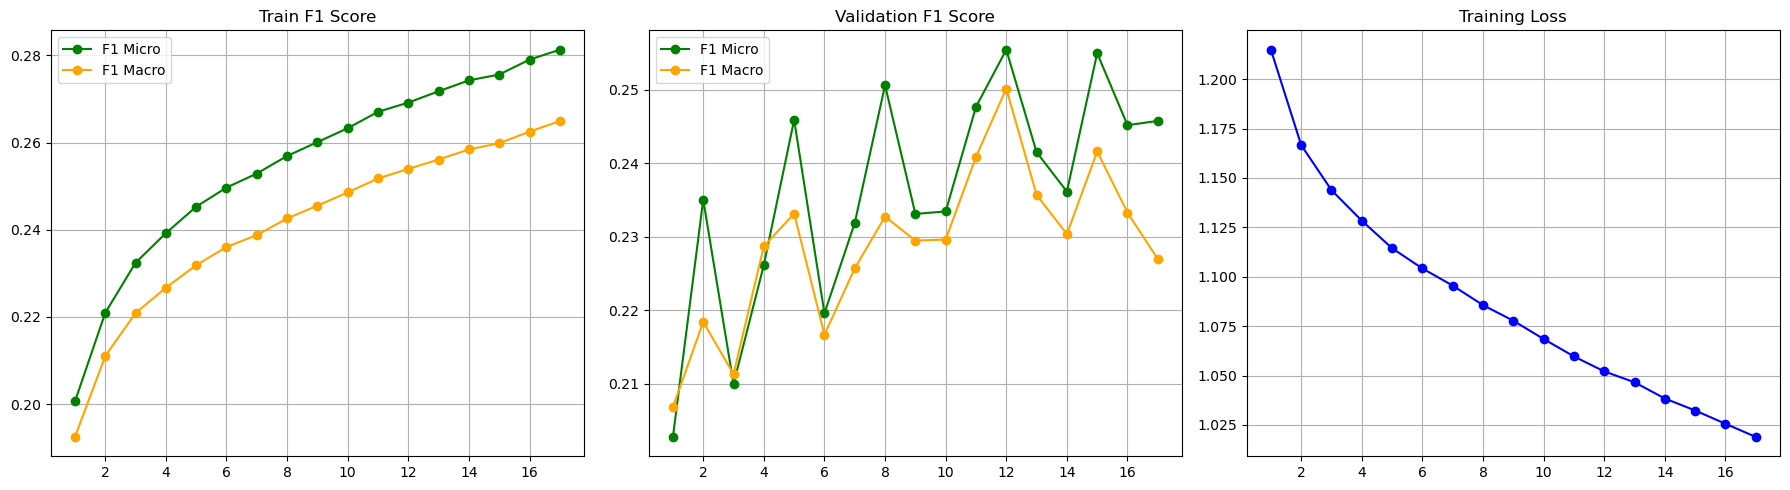

In [91]:
model = CNN_1(num_classes).to(device)
train(model, 'cnn1.1', learning_rate=0.001, num_epochs=test_epochs, batch_size=128)
#unstable val f1

Epoch 1/20 | Loss: 1.0066 | TRAIN F1 micro: 0.2876, macro: 0.2706 | VAL F1 micro: 0.2713, macro: 0.2463
Epoch 2/20 | Loss: 1.0005 | TRAIN F1 micro: 0.2895, macro: 0.2724 | VAL F1 micro: 0.2691, macro: 0.2454
Epoch 3/20 | Loss: 0.9964 | TRAIN F1 micro: 0.2908, macro: 0.2737 | VAL F1 micro: 0.2536, macro: 0.2414
Epoch 4/20 | Loss: 0.9926 | TRAIN F1 micro: 0.2922, macro: 0.2749 | VAL F1 micro: 0.2557, macro: 0.2358
Epoch 5/20 | Loss: 0.9882 | TRAIN F1 micro: 0.2929, macro: 0.2760 | VAL F1 micro: 0.2581, macro: 0.2447
Epoch 6/20 | Loss: 0.9849 | TRAIN F1 micro: 0.2941, macro: 0.2767 | VAL F1 micro: 0.2461, macro: 0.2358
Early stopping at epoch 6

Best model from epoch 1 | VAL F1 micro: 0.2713
TEST F1 micro: 0.2742, macro: 0.2432 | TEST accuracy: 0.7169


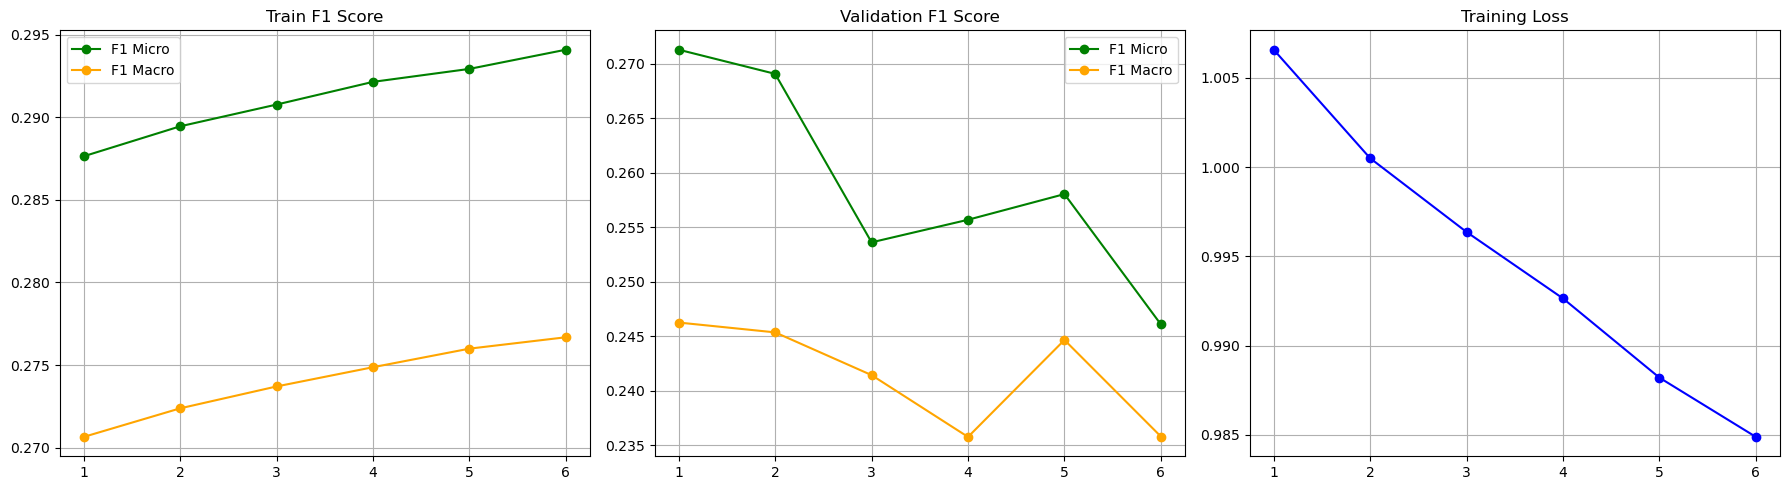

In [93]:
#smaller learning rate
train(model, 'cnn1.2', learning_rate=0.0005, num_epochs=test_epochs, batch_size=128)

Epoch 1/20 | Loss: 1.0087 | TRAIN F1 micro: 0.2856, macro: 0.2690 | VAL F1 micro: 0.2583, macro: 0.2457
Epoch 2/20 | Loss: 1.0035 | TRAIN F1 micro: 0.2889, macro: 0.2718 | VAL F1 micro: 0.2448, macro: 0.2309
Epoch 3/20 | Loss: 0.9979 | TRAIN F1 micro: 0.2893, macro: 0.2723 | VAL F1 micro: 0.2543, macro: 0.2298
Epoch 4/20 | Loss: 0.9937 | TRAIN F1 micro: 0.2909, macro: 0.2737 | VAL F1 micro: 0.2555, macro: 0.2346
Epoch 5/20 | Loss: 0.9895 | TRAIN F1 micro: 0.2927, macro: 0.2754 | VAL F1 micro: 0.2589, macro: 0.2365
Epoch 6/20 | Loss: 0.9849 | TRAIN F1 micro: 0.2938, macro: 0.2765 | VAL F1 micro: 0.2513, macro: 0.2377
Epoch 7/20 | Loss: 0.9804 | TRAIN F1 micro: 0.2953, macro: 0.2779 | VAL F1 micro: 0.2653, macro: 0.2413
Epoch 8/20 | Loss: 0.9768 | TRAIN F1 micro: 0.2973, macro: 0.2798 | VAL F1 micro: 0.2524, macro: 0.2367
Epoch 9/20 | Loss: 0.9746 | TRAIN F1 micro: 0.2969, macro: 0.2796 | VAL F1 micro: 0.2547, macro: 0.2332
Epoch 10/20 | Loss: 0.9679 | TRAIN F1 micro: 0.2994, macro: 0.28

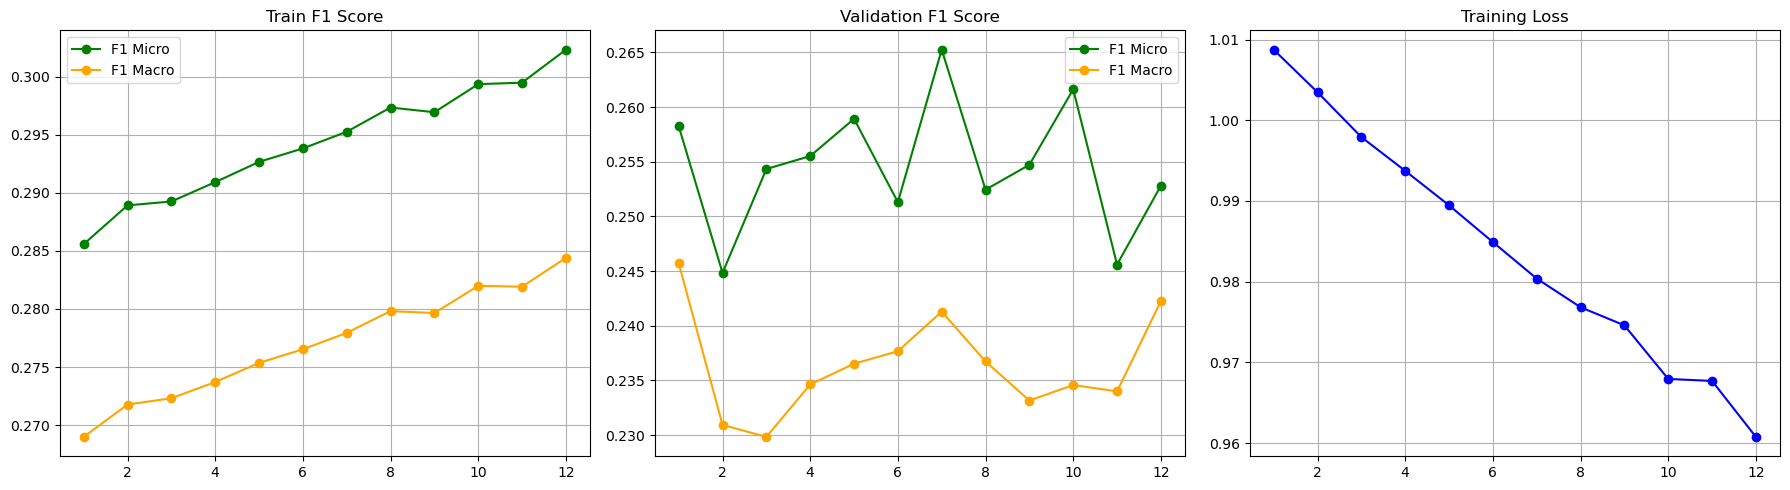

In [94]:
#bigger batch size
train(model, 'cnn1.3', learning_rate=0.001, num_epochs=test_epochs, batch_size=256)

Epoch 1/20 | Loss: 0.9542 | TRAIN F1 micro: 0.3066, macro: 0.2883 | VAL F1 micro: 0.2534, macro: 0.2400
Epoch 2/20 | Loss: 0.9501 | TRAIN F1 micro: 0.3082, macro: 0.2901 | VAL F1 micro: 0.2526, macro: 0.2332
Epoch 3/20 | Loss: 0.9468 | TRAIN F1 micro: 0.3081, macro: 0.2902 | VAL F1 micro: 0.2569, macro: 0.2399
Epoch 4/20 | Loss: 0.9449 | TRAIN F1 micro: 0.3092, macro: 0.2910 | VAL F1 micro: 0.2589, macro: 0.2402
Epoch 5/20 | Loss: 0.9425 | TRAIN F1 micro: 0.3104, macro: 0.2920 | VAL F1 micro: 0.2480, macro: 0.2329
Epoch 6/20 | Loss: 0.9409 | TRAIN F1 micro: 0.3104, macro: 0.2923 | VAL F1 micro: 0.2533, macro: 0.2385
Epoch 7/20 | Loss: 0.9390 | TRAIN F1 micro: 0.3106, macro: 0.2926 | VAL F1 micro: 0.2492, macro: 0.2338
Epoch 8/20 | Loss: 0.9366 | TRAIN F1 micro: 0.3122, macro: 0.2939 | VAL F1 micro: 0.2563, macro: 0.2383
Epoch 9/20 | Loss: 0.9352 | TRAIN F1 micro: 0.3129, macro: 0.2946 | VAL F1 micro: 0.2607, macro: 0.2411
Epoch 10/20 | Loss: 0.9323 | TRAIN F1 micro: 0.3130, macro: 0.29

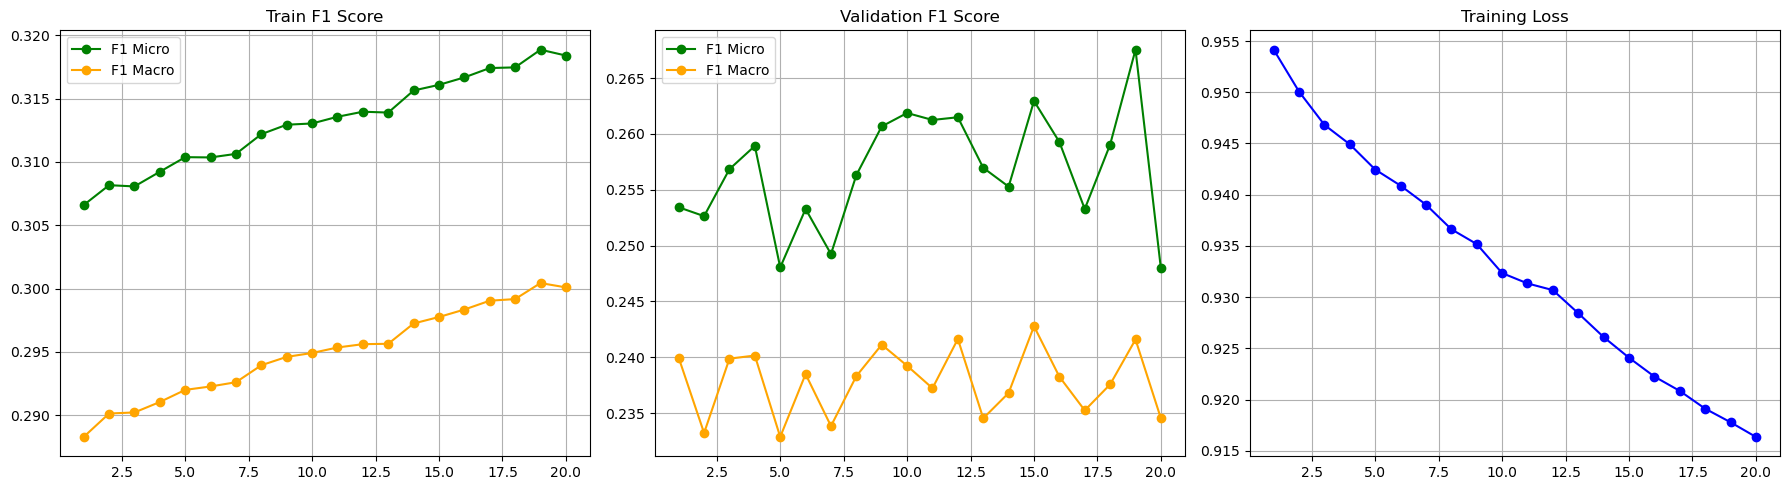

In [95]:
#smaller lr, bigger batch size
train(model, 'cnn1.4', learning_rate=0.0003, num_epochs=test_epochs, batch_size=256)

## CNN2: + regularisation (weight decay) with AdamW

Model still has a problem with generalisation, lets see if weight decay can help with that

In [ ]:
def train_with_decay(model, model_name, num_epochs=5, learning_rate=0.001, batch_size=100, patience=5, weight_decay=1e-4):
    train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

    # AdamW lepiej obsługuje weight decay niż standardowy Adam
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    train_losses = []
    train_f1_micro, train_f1_macro = [], []
    val_f1_micro, val_f1_macro = [], []
    
    best_val_f1 = 0.0
    epochs_no_improve = 0

    best_epoch = -1
    best_model_path = os.path.join(save_dir_cnn, model_name + '.pth')

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        all_pred_train, all_labels_train = [], []

        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = torch.from_numpy(labels).float().to(device) if isinstance(labels, np.ndarray) else labels.float().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            predicted = (torch.sigmoid(outputs) > 0.5).int()
            all_pred_train.append(predicted.cpu())
            all_labels_train.append(labels.cpu())

        all_pred_train = torch.cat(all_pred_train, dim=0).numpy()
        all_labels_train = torch.cat(all_labels_train, dim=0).numpy()

        f1_micro = f1_score(all_labels_train, all_pred_train, average='micro', zero_division=0)
        f1_macro = f1_score(all_labels_train, all_pred_train, average='macro', zero_division=0)

        train_losses.append(running_loss / len(train_loader))
        train_f1_micro.append(f1_micro)
        train_f1_macro.append(f1_macro)

        model.eval()
        all_pred_val, all_labels_val = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = torch.from_numpy(labels).float().to(device) if isinstance(labels, np.ndarray) else labels.float().to(device)
                outputs = model(images)
                predicted = (torch.sigmoid(outputs) > 0.5).int()
                all_pred_val.append(predicted.cpu())
                all_labels_val.append(labels.cpu())

        all_pred_val = torch.cat(all_pred_val, dim=0).numpy()
        all_labels_val = torch.cat(all_labels_val, dim=0).numpy()

        f1_micro_val = f1_score(all_labels_val, all_pred_val, average='micro', zero_division=0)
        f1_macro_val = f1_score(all_labels_val, all_pred_val, average='macro', zero_division=0)

        val_f1_micro.append(f1_micro_val)
        val_f1_macro.append(f1_macro_val)

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {train_losses[-1]:.4f} "
              f"| TRAIN F1 micro: {f1_micro:.4f}, macro: {f1_macro:.4f} "
              f"| VAL F1 micro: {f1_micro_val:.4f}, macro: {f1_macro_val:.4f}")

        # early stopping & save best model
        if f1_micro_val > best_val_f1:
            best_val_f1 = f1_micro_val
            best_epoch = epoch + 1
            torch.save(model.state_dict(), best_model_path)
            epochs_no_improve = 0

        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # testing
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
    all_pred_test, all_labels_test = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = torch.from_numpy(labels).float().to(device) if isinstance(labels, np.ndarray) else labels.float().to(device)
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > 0.5).int()
            all_pred_test.append(predicted.cpu())
            all_labels_test.append(labels.cpu())

    all_pred_test = torch.cat(all_pred_test, dim=0).numpy()
    all_labels_test = torch.cat(all_labels_test, dim=0).numpy()
    test_f1_micro = f1_score(all_labels_test, all_pred_test, average='micro', zero_division=0)
    test_f1_macro = f1_score(all_labels_test, all_pred_test, average='macro', zero_division=0)

    test_accuracy = (all_labels_test == all_pred_test).mean()

    print(
        f"\nBest model from epoch {best_epoch} | "
        f"VAL F1 micro: {best_val_f1:.4f}\n"
        f"TEST F1 micro: {test_f1_micro:.4f}, macro: {test_f1_macro:.4f} | "
        f"TEST accuracy: {test_accuracy:.4f}"
    )

    # plots
    epochs_range = range(1, len(train_losses) + 1)
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    axs[0].plot(epochs_range, train_f1_micro, marker='o', label='F1 Micro', color='green')
    axs[0].plot(epochs_range, train_f1_macro, marker='o', label='F1 Macro', color='orange')
    axs[0].set_title('Train F1 Score')
    axs[0].legend(); axs[0].grid(True)
    axs[1].plot(epochs_range, val_f1_micro, marker='o', label='F1 Micro', color='green')
    axs[1].plot(epochs_range, val_f1_macro, marker='o', label='F1 Macro', color='orange')
    axs[1].set_title('Validation F1 Score')
    axs[1].legend(); axs[1].grid(True)
    axs[2].plot(epochs_range, train_losses, marker='o', color='blue')
    axs[2].set_title('Training Loss')
    axs[2].grid(True)
    plt.tight_layout()
    plt.show()

### TEST CNN2 hiperparameters

Epoch 1/20 | Loss: 0.9128 | TRAIN F1 micro: 0.3179, macro: 0.2997 | VAL F1 micro: 0.2510, macro: 0.2369
Epoch 2/20 | Loss: 0.9091 | TRAIN F1 micro: 0.3197, macro: 0.3014 | VAL F1 micro: 0.2602, macro: 0.2383
Epoch 3/20 | Loss: 0.9070 | TRAIN F1 micro: 0.3200, macro: 0.3019 | VAL F1 micro: 0.2493, macro: 0.2361
Epoch 4/20 | Loss: 0.9045 | TRAIN F1 micro: 0.3213, macro: 0.3032 | VAL F1 micro: 0.2481, macro: 0.2270
Epoch 5/20 | Loss: 0.9028 | TRAIN F1 micro: 0.3217, macro: 0.3034 | VAL F1 micro: 0.2544, macro: 0.2348
Epoch 6/20 | Loss: 0.9015 | TRAIN F1 micro: 0.3213, macro: 0.3033 | VAL F1 micro: 0.2456, macro: 0.2312
Epoch 7/20 | Loss: 0.8981 | TRAIN F1 micro: 0.3229, macro: 0.3049 | VAL F1 micro: 0.2532, macro: 0.2351
Early stopping at epoch 7

Best model from epoch 2 | VAL F1 micro: 0.2602
TEST F1 micro: 0.2616, macro: 0.2367 | TEST accuracy: 0.7226


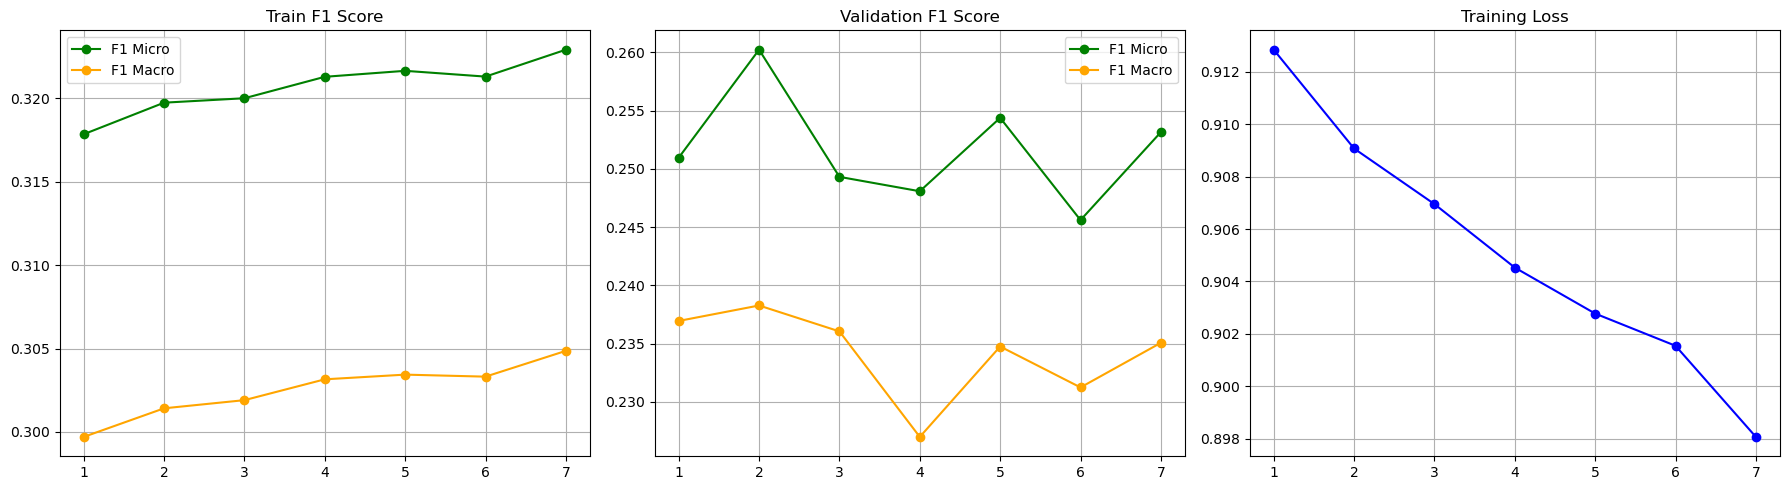

In [100]:
#best hiperparameters from previous experiments but lr increased because ADAMW with weight decay allows for higher learning rates
train_with_decay(model, 'cnn2.1', learning_rate=0.0006, num_epochs=test_epochs, batch_size=256, weight_decay=1e-4)

Epoch 1/20 | Loss: 0.9278 | TRAIN F1 micro: 0.3119, macro: 0.2940 | VAL F1 micro: 0.2494, macro: 0.2319
Epoch 2/20 | Loss: 0.9229 | TRAIN F1 micro: 0.3140, macro: 0.2960 | VAL F1 micro: 0.2371, macro: 0.2285
Epoch 3/20 | Loss: 0.9197 | TRAIN F1 micro: 0.3158, macro: 0.2976 | VAL F1 micro: 0.2582, macro: 0.2319
Epoch 4/20 | Loss: 0.9195 | TRAIN F1 micro: 0.3146, macro: 0.2965 | VAL F1 micro: 0.2543, macro: 0.2396
Epoch 5/20 | Loss: 0.9162 | TRAIN F1 micro: 0.3158, macro: 0.2981 | VAL F1 micro: 0.2542, macro: 0.2363
Epoch 6/20 | Loss: 0.9151 | TRAIN F1 micro: 0.3166, macro: 0.2985 | VAL F1 micro: 0.2468, macro: 0.2328
Epoch 7/20 | Loss: 0.9102 | TRAIN F1 micro: 0.3180, macro: 0.3001 | VAL F1 micro: 0.2457, macro: 0.2303
Epoch 8/20 | Loss: 0.9084 | TRAIN F1 micro: 0.3187, macro: 0.3006 | VAL F1 micro: 0.2484, macro: 0.2300
Early stopping at epoch 8

Best model from epoch 3 | VAL F1 micro: 0.2582
TEST F1 micro: 0.2621, macro: 0.2332 | TEST accuracy: 0.7261


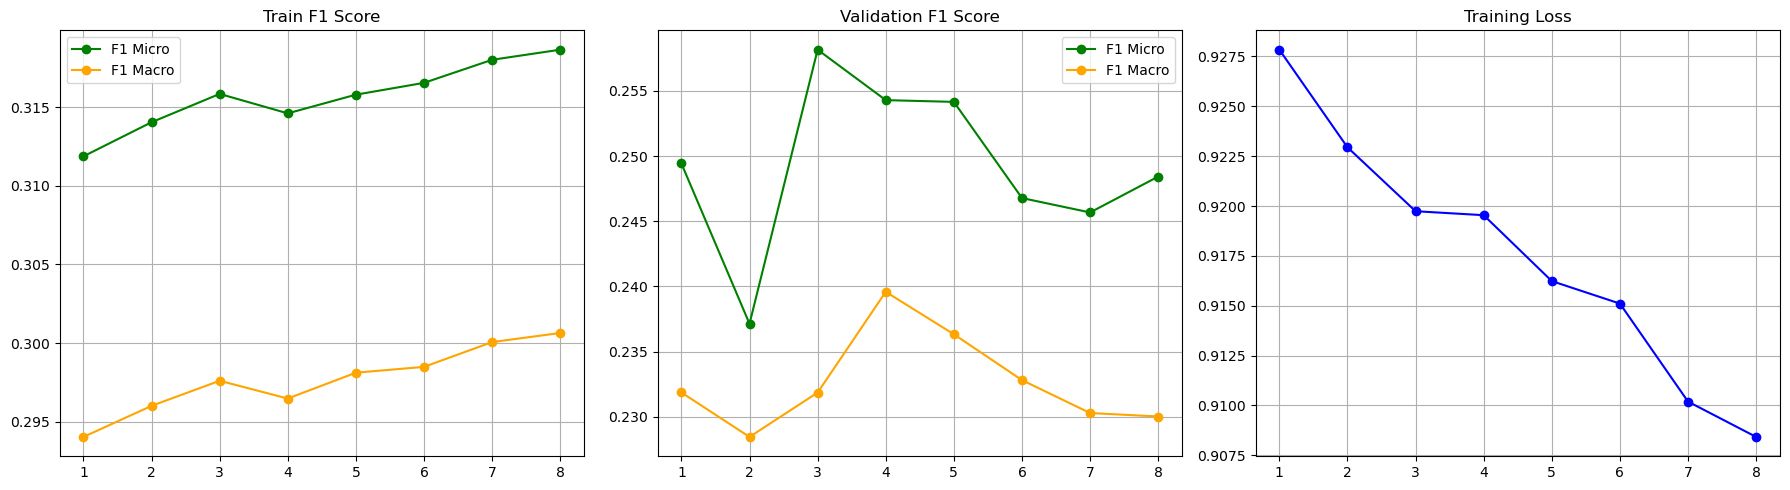

In [101]:
train_with_decay(model, 'cnn2.2', learning_rate=0.001, num_epochs=test_epochs, batch_size=256, weight_decay=1e-4)

Epoch 1/20 | Loss: 0.9022 | TRAIN F1 micro: 0.3219, macro: 0.3036 | VAL F1 micro: 0.2575, macro: 0.2355
Epoch 2/20 | Loss: 0.8978 | TRAIN F1 micro: 0.3233, macro: 0.3053 | VAL F1 micro: 0.2531, macro: 0.2358
Epoch 3/20 | Loss: 0.8950 | TRAIN F1 micro: 0.3237, macro: 0.3061 | VAL F1 micro: 0.2447, macro: 0.2255
Epoch 4/20 | Loss: 0.8955 | TRAIN F1 micro: 0.3236, macro: 0.3056 | VAL F1 micro: 0.2646, macro: 0.2362
Epoch 5/20 | Loss: 0.8917 | TRAIN F1 micro: 0.3252, macro: 0.3071 | VAL F1 micro: 0.2592, macro: 0.2369
Epoch 6/20 | Loss: 0.8880 | TRAIN F1 micro: 0.3264, macro: 0.3086 | VAL F1 micro: 0.2576, macro: 0.2337
Epoch 7/20 | Loss: 0.8885 | TRAIN F1 micro: 0.3260, macro: 0.3082 | VAL F1 micro: 0.2442, macro: 0.2301
Epoch 8/20 | Loss: 0.8855 | TRAIN F1 micro: 0.3273, macro: 0.3096 | VAL F1 micro: 0.2664, macro: 0.2366
Epoch 9/20 | Loss: 0.8864 | TRAIN F1 micro: 0.3270, macro: 0.3092 | VAL F1 micro: 0.2473, macro: 0.2284
Epoch 10/20 | Loss: 0.8819 | TRAIN F1 micro: 0.3291, macro: 0.31

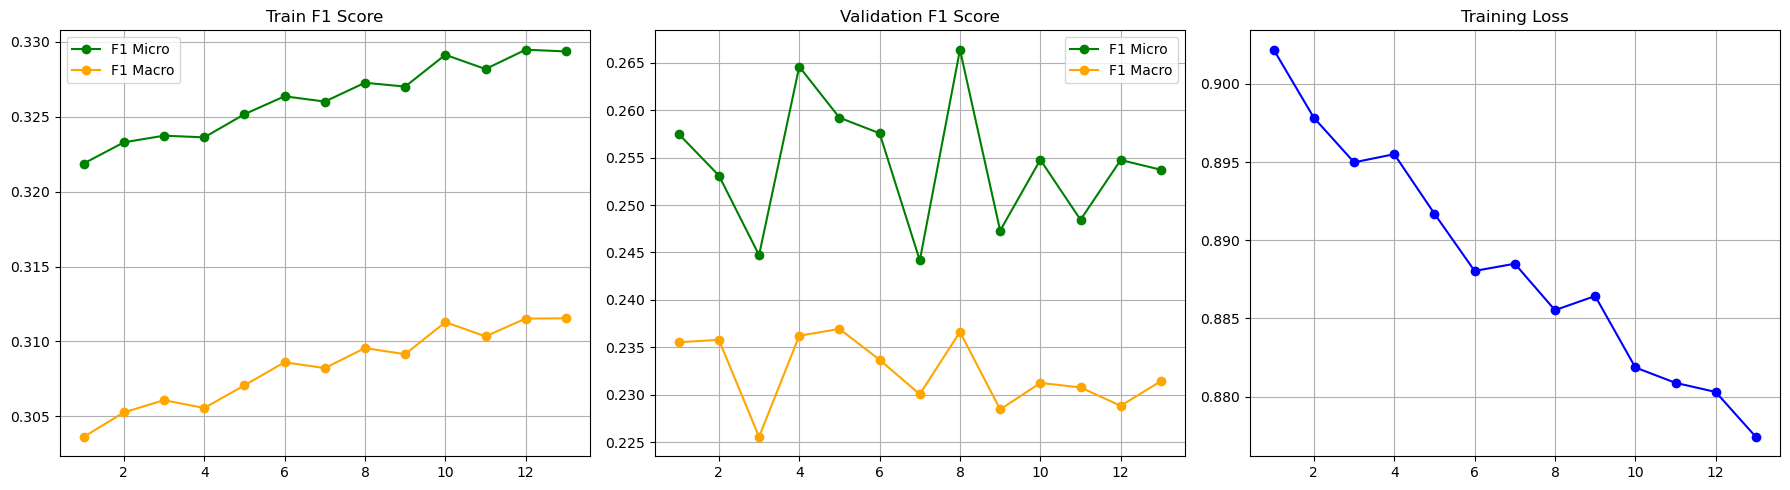

In [102]:
#bigger weight decay because of batch size
train_with_decay(model, 'cnn2.3', learning_rate=0.0006, num_epochs=test_epochs, batch_size=256, weight_decay=1e-3)

Epoch 1/20 | Loss: 0.8864 | TRAIN F1 micro: 0.3264, macro: 0.3085 | VAL F1 micro: 0.2546, macro: 0.2328
Epoch 2/20 | Loss: 0.8819 | TRAIN F1 micro: 0.3294, macro: 0.3113 | VAL F1 micro: 0.2551, macro: 0.2339
Epoch 3/20 | Loss: 0.8805 | TRAIN F1 micro: 0.3292, macro: 0.3114 | VAL F1 micro: 0.2600, macro: 0.2367
Epoch 4/20 | Loss: 0.8799 | TRAIN F1 micro: 0.3292, macro: 0.3113 | VAL F1 micro: 0.2443, macro: 0.2275
Epoch 5/20 | Loss: 0.8775 | TRAIN F1 micro: 0.3296, macro: 0.3120 | VAL F1 micro: 0.2454, macro: 0.2261
Epoch 6/20 | Loss: 0.8784 | TRAIN F1 micro: 0.3297, macro: 0.3115 | VAL F1 micro: 0.2530, macro: 0.2353
Epoch 7/20 | Loss: 0.8750 | TRAIN F1 micro: 0.3304, macro: 0.3126 | VAL F1 micro: 0.2504, macro: 0.2326
Epoch 8/20 | Loss: 0.8760 | TRAIN F1 micro: 0.3294, macro: 0.3117 | VAL F1 micro: 0.2559, macro: 0.2330
Early stopping at epoch 8

Best model from epoch 3 | VAL F1 micro: 0.2600
TEST F1 micro: 0.2615, macro: 0.2352 | TEST accuracy: 0.7292


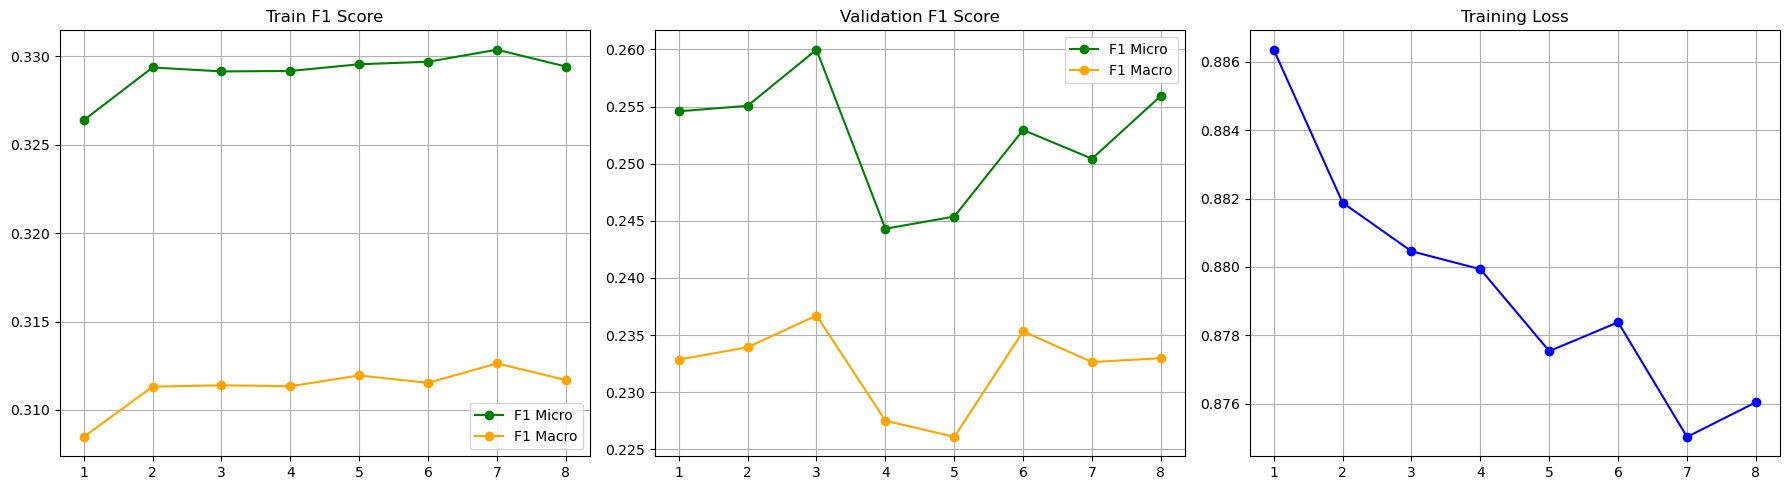

In [103]:
#bigger weight decay because of batch size
train_with_decay(model, 'cnn2.4', learning_rate=0.0006, num_epochs=test_epochs, batch_size=256, weight_decay=1e-2)

Epoch 1/20 | Loss: 0.9033 | TRAIN F1 micro: 0.3201, macro: 0.3023 | VAL F1 micro: 0.2505, macro: 0.2260
Epoch 2/20 | Loss: 0.9002 | TRAIN F1 micro: 0.3219, macro: 0.3039 | VAL F1 micro: 0.2618, macro: 0.2388
Epoch 3/20 | Loss: 0.9007 | TRAIN F1 micro: 0.3214, macro: 0.3035 | VAL F1 micro: 0.2421, macro: 0.2339
Epoch 4/20 | Loss: 0.8990 | TRAIN F1 micro: 0.3207, macro: 0.3031 | VAL F1 micro: 0.2602, macro: 0.2382
Epoch 5/20 | Loss: 0.8988 | TRAIN F1 micro: 0.3213, macro: 0.3034 | VAL F1 micro: 0.2532, macro: 0.2333
Epoch 6/20 | Loss: 0.9007 | TRAIN F1 micro: 0.3201, macro: 0.3023 | VAL F1 micro: 0.2425, macro: 0.2248
Epoch 7/20 | Loss: 0.9018 | TRAIN F1 micro: 0.3205, macro: 0.3025 | VAL F1 micro: 0.2527, macro: 0.2322
Early stopping at epoch 7

Best model from epoch 2 | VAL F1 micro: 0.2618
TEST F1 micro: 0.2613, macro: 0.2366 | TEST accuracy: 0.7577


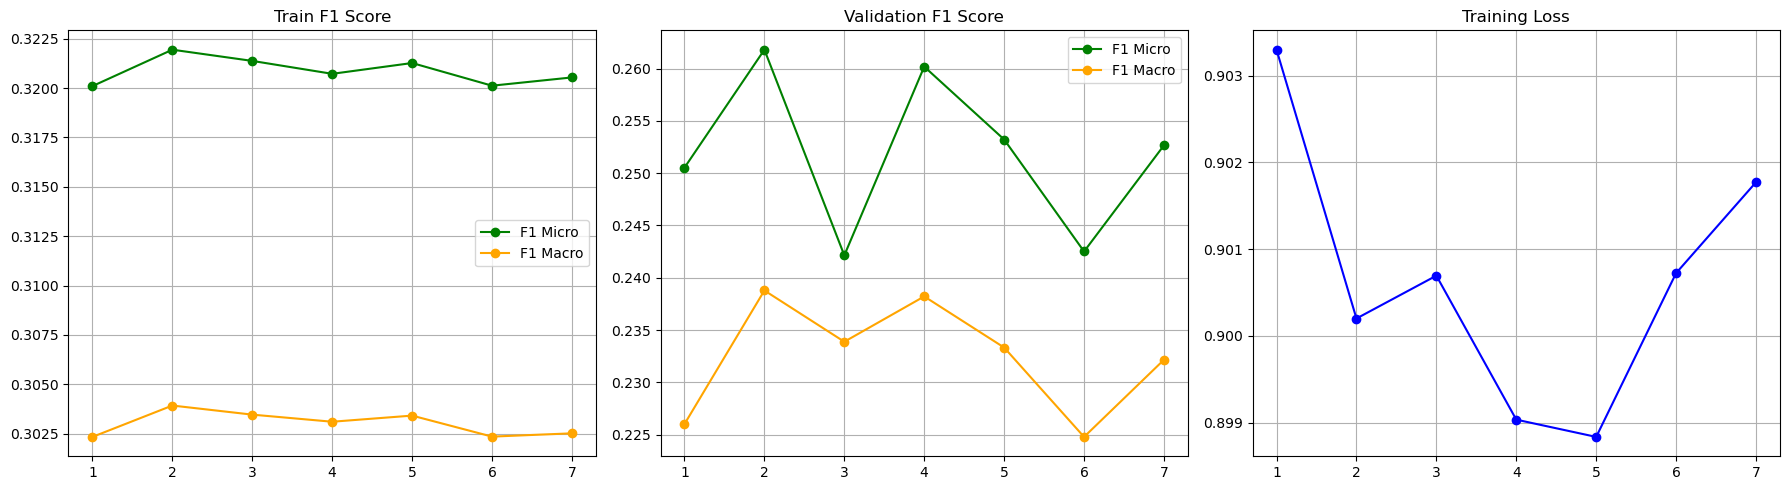

In [104]:
#agressive regularisation
train_with_decay(model, 'cnn2.5', learning_rate=0.001, num_epochs=test_epochs, batch_size=256, weight_decay=0.05)

Epoch 1/20 | Loss: 1.0543 | TRAIN F1 micro: 0.2672, macro: 0.2519 | VAL F1 micro: 0.2426, macro: 0.2239
Epoch 2/20 | Loss: 1.0467 | TRAIN F1 micro: 0.2691, macro: 0.2534 | VAL F1 micro: 0.2575, macro: 0.2372
Epoch 3/20 | Loss: 1.0474 | TRAIN F1 micro: 0.2684, macro: 0.2528 | VAL F1 micro: 0.2309, macro: 0.2244
Epoch 4/20 | Loss: 1.0551 | TRAIN F1 micro: 0.2658, macro: 0.2506 | VAL F1 micro: 0.2367, macro: 0.2289
Epoch 5/20 | Loss: 1.0560 | TRAIN F1 micro: 0.2655, macro: 0.2500 | VAL F1 micro: 0.2205, macro: 0.2156
Epoch 6/20 | Loss: 1.0600 | TRAIN F1 micro: 0.2647, macro: 0.2496 | VAL F1 micro: 0.2357, macro: 0.2209
Epoch 7/20 | Loss: 1.0596 | TRAIN F1 micro: 0.2639, macro: 0.2490 | VAL F1 micro: 0.2493, macro: 0.2409
Early stopping at epoch 7

Best model from epoch 2 | VAL F1 micro: 0.2575
TEST F1 micro: 0.2564, macro: 0.2348 | TEST accuracy: 0.6991


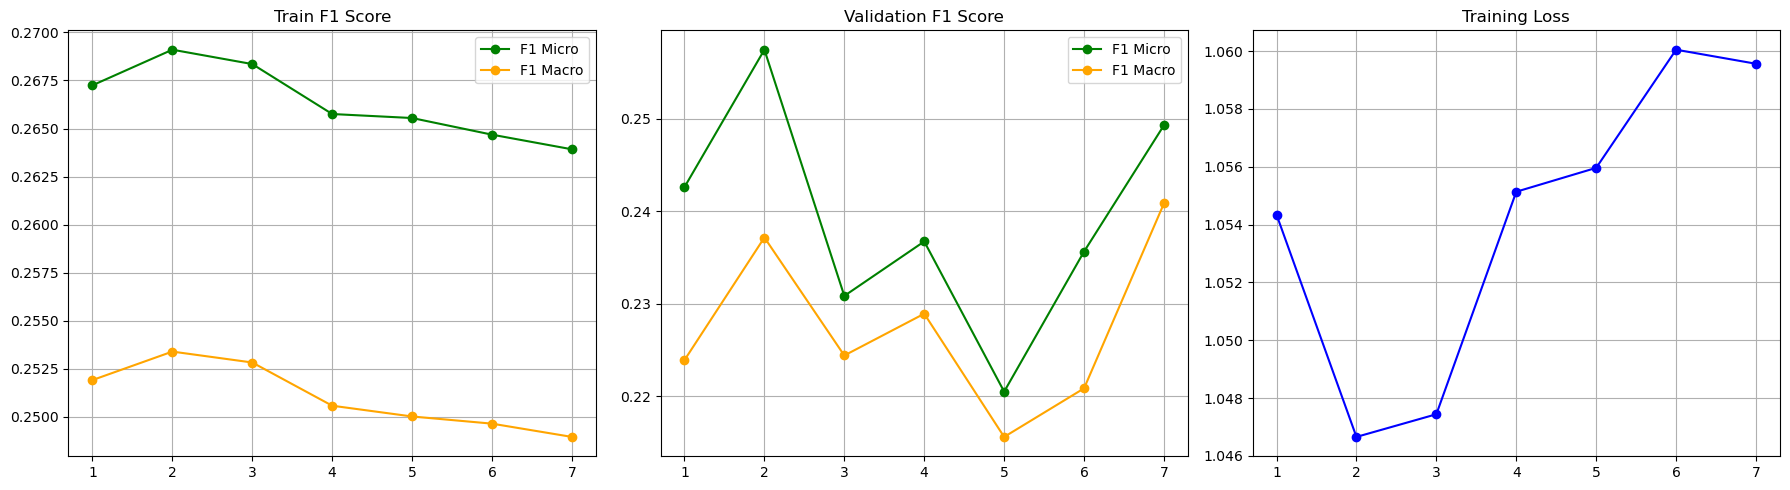

In [105]:
#hight lr & weight decay
train_with_decay(model, 'cnn2.6', learning_rate=0.005, num_epochs=test_epochs, batch_size=256, weight_decay=0.1)

## CNN3: +dropout 

In [33]:
dropout_prob = 0.5
class CNN_3(nn.Module):
    def __init__(self, num_classes):
        super(CNN_3, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=2), 
            nn.BatchNorm2d(16),     # Batch normalization: normalizes feature maps to stabilize and speed up training
            nn.ReLU(),              # ReLU activation: introduces non-linearity
            nn.MaxPool2d(kernel_size=2, stride=2))  # Max pooling: reduces dimensions by taking the max in each 2x2 window
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),  # Second convolutional layer: increases feature depth (32)
            nn.BatchNorm2d(32),                                     # Normalization after convolution
            nn.ReLU(),                                             
            nn.MaxPool2d(kernel_size=2, stride=2))                 
        self.fc = nn.Linear(7*7*32, 128)  # Fully connected layer: maps flattened features to output classes
        self.dropout = nn.Dropout(dropout_prob)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        out = self.layer1(x)                  
        out = self.layer2(out)                
        out = out.reshape(out.size(0), -1)    #flatten the output to (batch_size, features)
        out = self.fc(out)                    #pass through the fc layer for classification
        out = self.dropout(out)
        out = self.fc2(out)                 #pass through the fc layer for classification
        return out

Epoch 1/20 | Loss: 1.2311 | TRAIN F1 micro: 0.1941, macro: 0.1860 | VAL F1 micro: 0.2166, macro: 0.2036
Epoch 2/20 | Loss: 1.1796 | TRAIN F1 micro: 0.2156, macro: 0.2058 | VAL F1 micro: 0.2017, macro: 0.2010
Epoch 3/20 | Loss: 1.1587 | TRAIN F1 micro: 0.2255, macro: 0.2134 | VAL F1 micro: 0.2179, macro: 0.2219
Epoch 4/20 | Loss: 1.1458 | TRAIN F1 micro: 0.2312, macro: 0.2187 | VAL F1 micro: 0.2392, macro: 0.2276
Epoch 5/20 | Loss: 1.1351 | TRAIN F1 micro: 0.2357, macro: 0.2238 | VAL F1 micro: 0.2569, macro: 0.2359
Epoch 6/20 | Loss: 1.1264 | TRAIN F1 micro: 0.2409, macro: 0.2274 | VAL F1 micro: 0.2253, macro: 0.2221
Epoch 7/20 | Loss: 1.1197 | TRAIN F1 micro: 0.2437, macro: 0.2302 | VAL F1 micro: 0.2572, macro: 0.2405
Epoch 8/20 | Loss: 1.1103 | TRAIN F1 micro: 0.2461, macro: 0.2331 | VAL F1 micro: 0.2299, macro: 0.2234
Epoch 9/20 | Loss: 1.1038 | TRAIN F1 micro: 0.2491, macro: 0.2354 | VAL F1 micro: 0.2387, macro: 0.2284
Epoch 10/20 | Loss: 1.0967 | TRAIN F1 micro: 0.2522, macro: 0.23

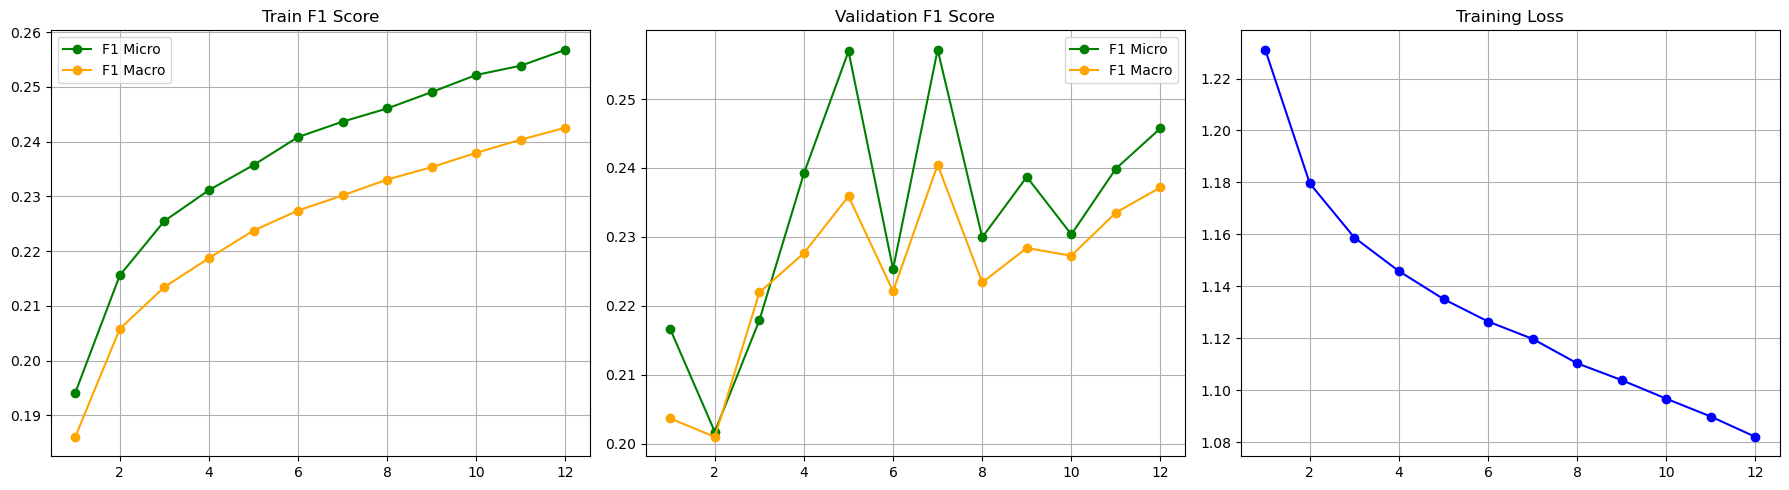

In [35]:
dropout_prob = 0.5
model = CNN_3(num_classes).to(device)
train(model, 'cnn3.1', learning_rate=0.0005, num_epochs=test_epochs, batch_size=128)

Epoch 1/20 | Loss: 1.2186 | TRAIN F1 micro: 0.1987, macro: 0.1907 | VAL F1 micro: 0.2053, macro: 0.2173
Epoch 2/20 | Loss: 1.1705 | TRAIN F1 micro: 0.2194, macro: 0.2092 | VAL F1 micro: 0.2361, macro: 0.2277
Epoch 3/20 | Loss: 1.1506 | TRAIN F1 micro: 0.2293, macro: 0.2177 | VAL F1 micro: 0.2238, macro: 0.2208
Epoch 4/20 | Loss: 1.1372 | TRAIN F1 micro: 0.2340, macro: 0.2218 | VAL F1 micro: 0.2205, macro: 0.2202
Epoch 5/20 | Loss: 1.1271 | TRAIN F1 micro: 0.2392, macro: 0.2265 | VAL F1 micro: 0.2385, macro: 0.2295
Epoch 6/20 | Loss: 1.1179 | TRAIN F1 micro: 0.2433, macro: 0.2303 | VAL F1 micro: 0.2404, macro: 0.2303
Epoch 7/20 | Loss: 1.1096 | TRAIN F1 micro: 0.2456, macro: 0.2326 | VAL F1 micro: 0.2400, macro: 0.2241
Epoch 8/20 | Loss: 1.1048 | TRAIN F1 micro: 0.2481, macro: 0.2347 | VAL F1 micro: 0.2330, macro: 0.2320
Epoch 9/20 | Loss: 1.0998 | TRAIN F1 micro: 0.2498, macro: 0.2363 | VAL F1 micro: 0.2523, macro: 0.2422
Epoch 10/20 | Loss: 1.0895 | TRAIN F1 micro: 0.2546, macro: 0.24

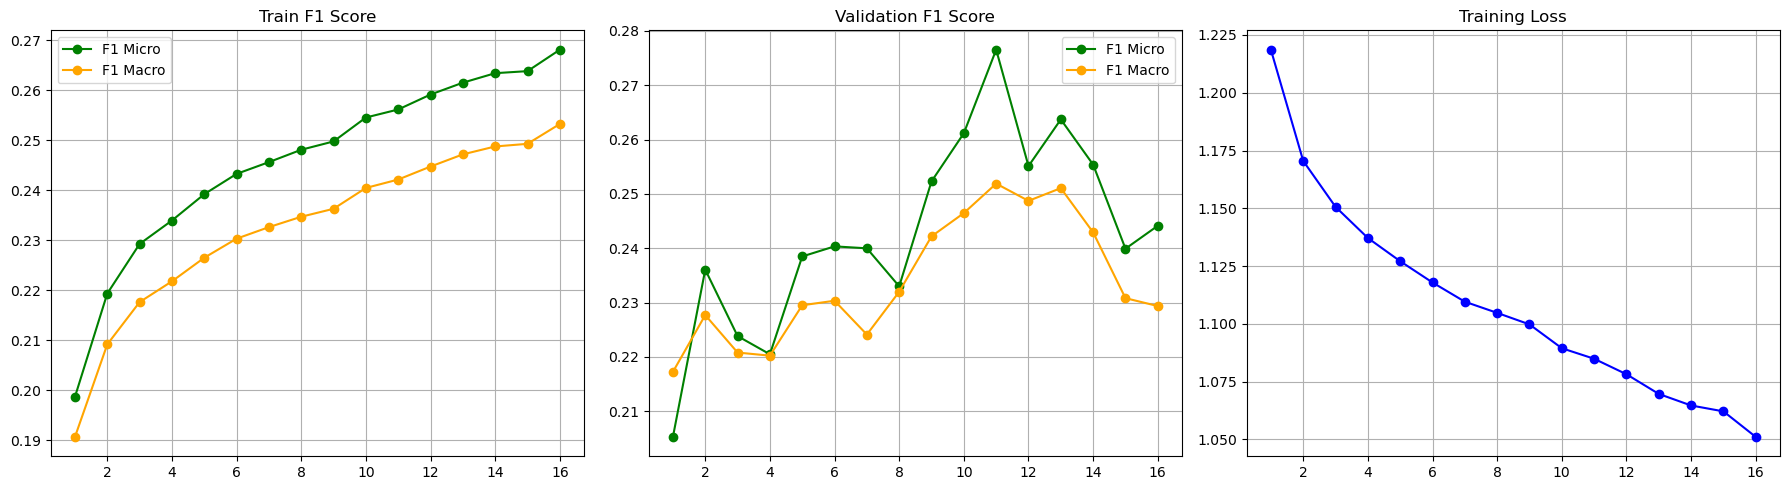

In [39]:
dropout_prob = 0.3
model = CNN_3(num_classes).to(device)
train_with_decay(model, 'cnn3.2', learning_rate=0.0006, num_epochs=test_epochs, batch_size=256, weight_decay=1e-2)

Epoch 1/20 | Loss: 1.2502 | TRAIN F1 micro: 0.1870, macro: 0.1797 | VAL F1 micro: 0.2115, macro: 0.1946
Epoch 2/20 | Loss: 1.1989 | TRAIN F1 micro: 0.2058, macro: 0.1970 | VAL F1 micro: 0.2198, macro: 0.2220
Epoch 3/20 | Loss: 1.1760 | TRAIN F1 micro: 0.2172, macro: 0.2064 | VAL F1 micro: 0.2180, macro: 0.2133
Epoch 4/20 | Loss: 1.1618 | TRAIN F1 micro: 0.2237, macro: 0.2125 | VAL F1 micro: 0.2048, macro: 0.2062
Epoch 5/20 | Loss: 1.1535 | TRAIN F1 micro: 0.2276, macro: 0.2158 | VAL F1 micro: 0.2105, macro: 0.2132
Epoch 6/20 | Loss: 1.1448 | TRAIN F1 micro: 0.2303, macro: 0.2185 | VAL F1 micro: 0.2219, macro: 0.2115
Epoch 7/20 | Loss: 1.1378 | TRAIN F1 micro: 0.2351, macro: 0.2228 | VAL F1 micro: 0.2523, macro: 0.2368
Epoch 8/20 | Loss: 1.1301 | TRAIN F1 micro: 0.2376, macro: 0.2253 | VAL F1 micro: 0.2518, macro: 0.2306
Epoch 9/20 | Loss: 1.1229 | TRAIN F1 micro: 0.2403, macro: 0.2272 | VAL F1 micro: 0.2569, macro: 0.2420
Epoch 10/20 | Loss: 1.1194 | TRAIN F1 micro: 0.2426, macro: 0.22

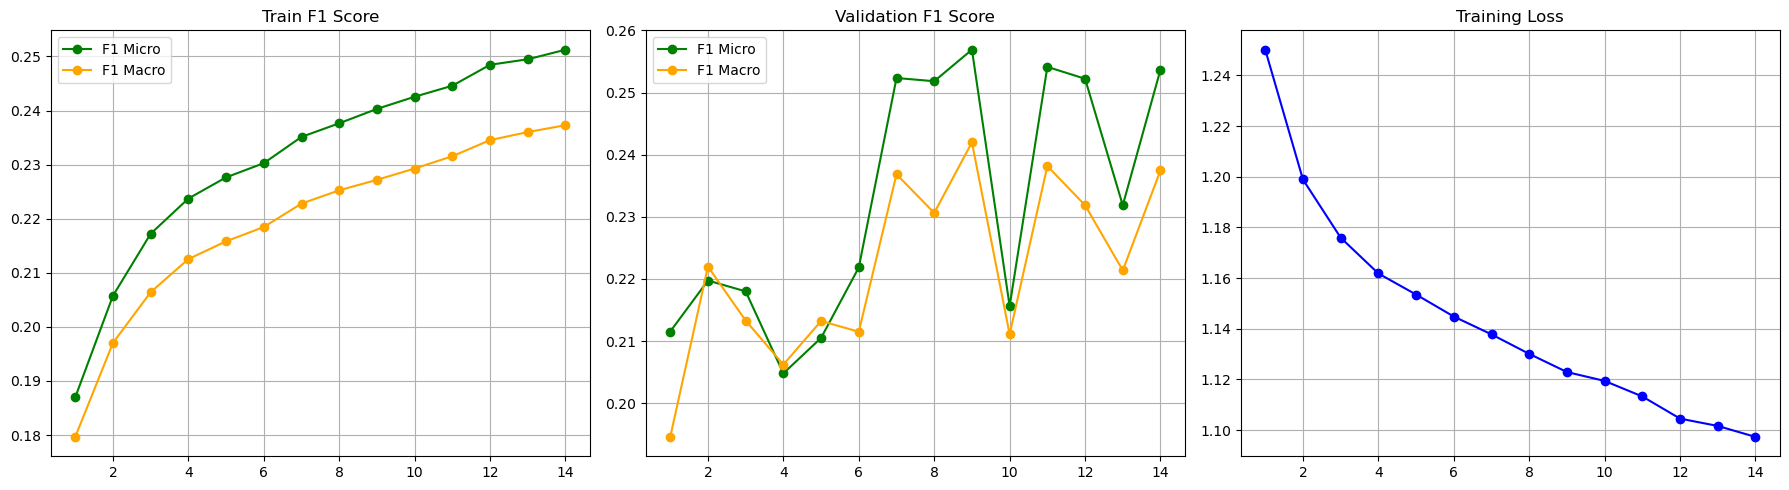

In [40]:
dropout_prob = 0.7
model = CNN_3(num_classes).to(device)
train_with_decay(model, 'cnn3.3', learning_rate=0.0006, num_epochs=test_epochs, batch_size=256, weight_decay=1e-2)

## CNN4: +more layers

In [51]:
dropout_prob = 0.5
class CNN_4(nn.Module):
    def __init__(self, num_classes):
        super(CNN_4, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=2), 
            nn.BatchNorm2d(16),     # Batch normalization: normalizes feature maps to stabilize and speed up training
            nn.ReLU(),              # ReLU activation: introduces non-linearity
            nn.MaxPool2d(kernel_size=2, stride=2))  # Max pooling: reduces dimensions by taking the max in each 2x2 window
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),  # Second convolutional layer: increases feature depth (32)
            nn.BatchNorm2d(32),                                     # Normalization after convolution
            nn.ReLU(),                                             
            nn.MaxPool2d(kernel_size=2, stride=2))  
        
        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )               
        self.fc = nn.Linear(576, 128)  # Fully connected layer: maps flattened features to output classes
        self.dropout = nn.Dropout(dropout_prob)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        out = self.layer1(x)                  
        out = self.layer2(out)  
        out = self.layer3(out)              
        out = out.reshape(out.size(0), -1)    #flatten the output to (batch_size, features)
        out = self.fc(out)                    #pass through the fc layer for classification
        out = self.dropout(out)
        out = self.fc2(out)                 #pass through the fc layer for classification
        return out

Epoch 1/20 | Loss: 1.2003 | TRAIN F1 micro: 0.2046, macro: 0.1957 | VAL F1 micro: 0.2073, macro: 0.2088
Epoch 2/20 | Loss: 1.1525 | TRAIN F1 micro: 0.2272, macro: 0.2156 | VAL F1 micro: 0.2361, macro: 0.2247
Epoch 3/20 | Loss: 1.1310 | TRAIN F1 micro: 0.2363, macro: 0.2245 | VAL F1 micro: 0.2541, macro: 0.2366
Epoch 4/20 | Loss: 1.1158 | TRAIN F1 micro: 0.2421, macro: 0.2294 | VAL F1 micro: 0.2246, macro: 0.2101
Epoch 5/20 | Loss: 1.1034 | TRAIN F1 micro: 0.2480, macro: 0.2348 | VAL F1 micro: 0.2340, macro: 0.2245
Epoch 6/20 | Loss: 1.0883 | TRAIN F1 micro: 0.2532, macro: 0.2396 | VAL F1 micro: 0.2536, macro: 0.2409
Epoch 7/20 | Loss: 1.0790 | TRAIN F1 micro: 0.2561, macro: 0.2425 | VAL F1 micro: 0.2692, macro: 0.2475
Epoch 8/20 | Loss: 1.0678 | TRAIN F1 micro: 0.2594, macro: 0.2456 | VAL F1 micro: 0.2469, macro: 0.2411
Epoch 9/20 | Loss: 1.0571 | TRAIN F1 micro: 0.2646, macro: 0.2502 | VAL F1 micro: 0.2538, macro: 0.2453
Epoch 10/20 | Loss: 1.0480 | TRAIN F1 micro: 0.2670, macro: 0.25

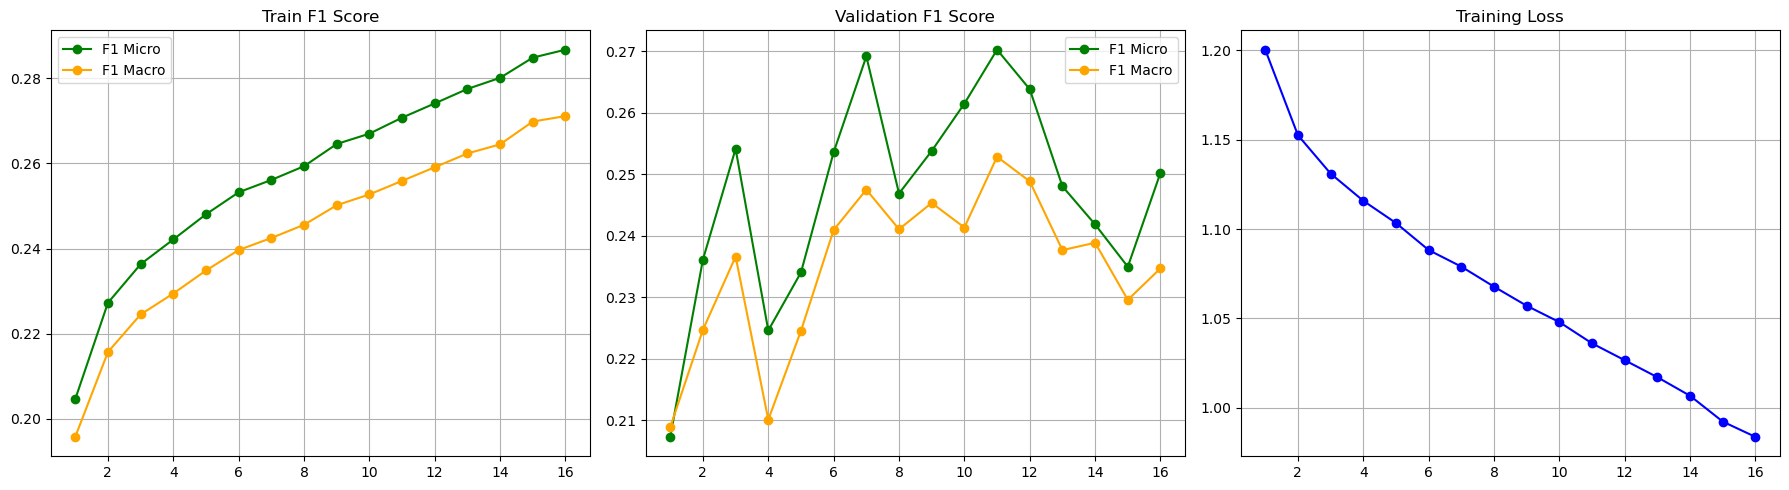

In [52]:
dropout_prob = 0.3
model = CNN_4(num_classes).to(device)
train_with_decay(model, 'cnn4.1', learning_rate=0.0006, num_epochs=test_epochs, batch_size=256, weight_decay=1e-2)

Epoch 1/100 | Loss: 1.2069 | TRAIN F1 micro: 0.2016, macro: 0.1921 | VAL F1 micro: 0.1909, macro: 0.1885
Epoch 2/100 | Loss: 1.1594 | TRAIN F1 micro: 0.2242, macro: 0.2130 | VAL F1 micro: 0.2319, macro: 0.2234
Epoch 3/100 | Loss: 1.1348 | TRAIN F1 micro: 0.2356, macro: 0.2230 | VAL F1 micro: 0.2250, macro: 0.2224
Epoch 4/100 | Loss: 1.1201 | TRAIN F1 micro: 0.2417, macro: 0.2283 | VAL F1 micro: 0.2518, macro: 0.2376
Epoch 5/100 | Loss: 1.1038 | TRAIN F1 micro: 0.2483, macro: 0.2349 | VAL F1 micro: 0.2415, macro: 0.2378
Epoch 6/100 | Loss: 1.0947 | TRAIN F1 micro: 0.2512, macro: 0.2376 | VAL F1 micro: 0.2351, macro: 0.2234
Epoch 7/100 | Loss: 1.0835 | TRAIN F1 micro: 0.2564, macro: 0.2420 | VAL F1 micro: 0.2582, macro: 0.2408
Epoch 8/100 | Loss: 1.0724 | TRAIN F1 micro: 0.2587, macro: 0.2448 | VAL F1 micro: 0.2534, macro: 0.2450
Epoch 9/100 | Loss: 1.0618 | TRAIN F1 micro: 0.2626, macro: 0.2482 | VAL F1 micro: 0.2568, macro: 0.2366
Epoch 10/100 | Loss: 1.0483 | TRAIN F1 micro: 0.2676, m

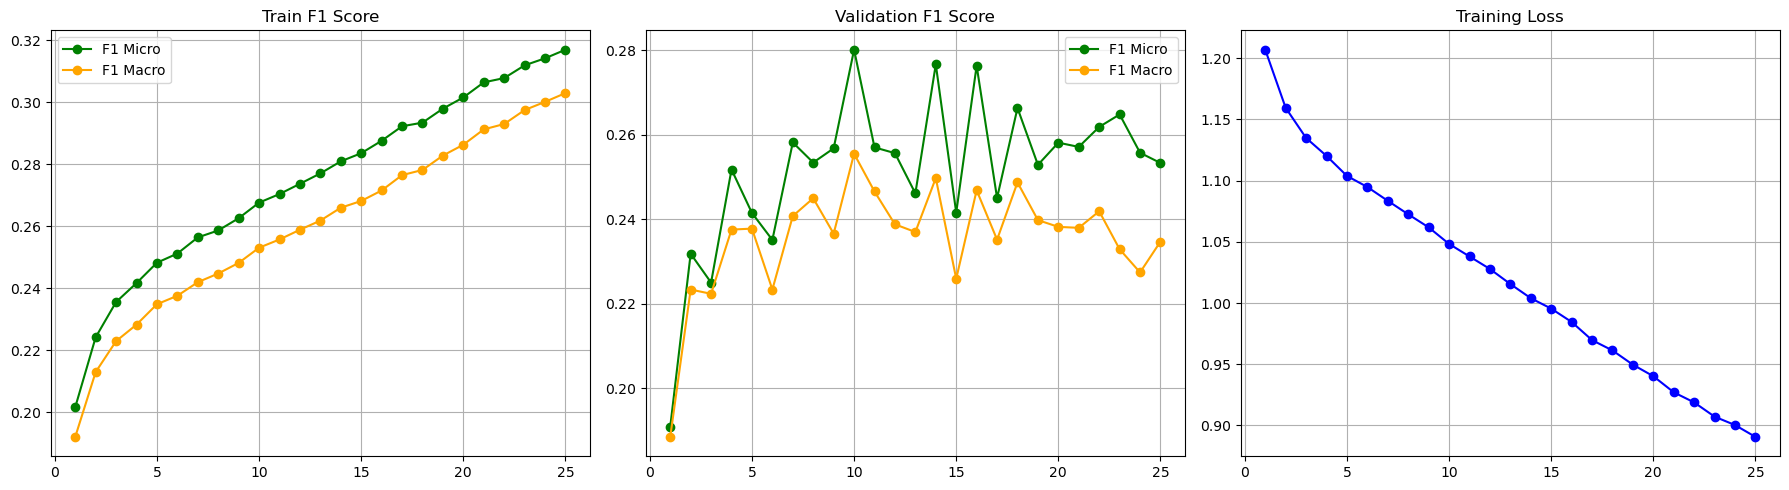

In [54]:
dropout_prob = 0.3
model = CNN_4(num_classes).to(device)
train_with_decay(model, 'cnn4.1', learning_rate=0.0006, num_epochs=100, batch_size=256, weight_decay=1e-2, patience=15)

# Feature exctraction

1. **HOG (Histogram of Oriented Gradients)**

* Focuses on edges and shapes.
* Preserves information about the gradient directions in local blocks, so it captures structures and contours well.
* Does not capture fine textures or high-frequency details effectively.

2. **LoG (Laplacian of Gaussian)**

* Focuses on regions with sudden intensity changes, such as edges and blobs.
* More sensitive to small details and fine structures than HOG, especially after Gaussian smoothing.
* Does not provide gradient direction histograms—only highlights where rapid intensity changes occur.

3. **LBP (Local Binary Patterns)**

* Focuses on local texture and micro-patterns.
* Independent of gradient direction or global shapes.
* Very effective for recognizing repeating structures and fine patterns (e.g., in tissues or surfaces).

In [55]:
import torch
import numpy as np
from skimage.feature import hog
from skimage.filters import gabor
from scipy.ndimage import gaussian_laplace

In [56]:
checkpoint = torch.load('datasets_all.pt')
train_dataset = checkpoint['train']
val_dataset = checkpoint['val']
test_dataset = checkpoint['test']

## HOG

HOG (Histogram of Oriented Gradients) focuses on **capturing the shape and structure of objects in an image** by analyzing the **distribution of gradient orientations** in localized regions. It emphasizes **edges, contours, and texture patterns**, making it robust to small variations in illumination while retaining important spatial information.


In [ ]:
def tensor_to_numpy(img_tensor):
    return img_tensor.squeeze().numpy()  

def apply_hog(dataset):
    hog_features = []
    for img, label in dataset:
        img_np = tensor_to_numpy(img)
        # HOG zwraca wektor cech
        features = hog(img_np, pixels_per_cell=(2, 2), #images are small so i want to capture fine details
                          cells_per_block=(1, 1), #also for small details
                          visualize=False, 
                          orientations=9,
                          feature_vector=True)
        hog_features.append((features, label))
    return hog_features


train_hog = apply_hog(train_dataset)
val_hog   = apply_hog(val_dataset)
test_hog  = apply_hog(test_dataset)

torch.save({
    'train': train_hog,
    'val': val_hog,
    'test': test_hog
}, 'hog_all.pt')

In [ ]:
print(train_hog)

In [ ]:
print(train_hog[0][0].shape)  
counter = 0

for i in train_hog[0][0]:
    if i ==0:
        counter += 1
print(counter)
#lots of zeroes in HOG features, PCA or random forest feature selection could help

(1764,)
1764
1764
1295


feature vecrot consist mainly of 0's so were gonna perform feature selection by random forest

In [58]:
import torch
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.inspection import permutation_importance

data = torch.load('hog_all.pt')

In [59]:
def unpack(dataset):
    X = np.stack([x for x, y in dataset])
    y = np.stack([y for x, y in dataset])
    return X, y

X_train, y_train = unpack(data['train'])
X_val, y_val     = unpack(data['val'])

feature selection failed, not enough memory on my lapotp

In [ ]:
n_labels = y_train.shape[1]
n_features = X_train.shape[1]

# train multioutput random forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

#classifier for multi-label problems
model = MultiOutputClassifier(rf, n_jobs=-1)
model.fit(X_train, y_train)

#permutation importance per label
importances = np.zeros((n_labels, n_features))

for i, estimator in enumerate(model.estimators_):
    r = permutation_importance(
        estimator,
        X_val,
        y_val[:, i],
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )
    importances[i] = r.importances_mean

# aggregate importance
# opcje: mean / max
importance_mean = importances.mean(axis=0)

#select top-k features
k = 500   
idx = np.argsort(importance_mean)[::-1][:k]

#apply selection
X_train_sel = X_train[:, idx]
X_val_sel   = X_val[:, idx]

c:\Users\kajaw\miniconda3\envs\ML\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\kajaw\miniconda3\envs\ML\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


## LBP

LBP (Local Binary Patterns) focuses on **capturing local texture information** in an image. For each pixel, it compares the intensity with its neighbors and encodes the pattern of **which neighbors are brighter or darker** as a binary number. This makes LBP robust for **texture and micro-pattern recognition**, such as detecting spots, edges, or repeated local structures, and it is **rotation-invariant and simple to compute**.


In [ ]:
from skimage.feature import local_binary_pattern
import numpy as np
import torch

radius = 1
n_points = 8 * radius
method = 'uniform'

def apply_lbp(dataset, radius=radius, n_points=n_points, method=method):
    lbp_features = []
    for img, label in dataset:
        img_np = tensor_to_numpy(img)
        lbp_img = local_binary_pattern(img_np, P=n_points, R=radius, method=method)
        # histogram jako feature vector
        n_bins = int(lbp_img.max() + 1)
        hist, _ = np.histogram(lbp_img, bins=n_bins, range=(0, n_bins), density=True)
        
        lbp_features.append((hist, label))
    return lbp_features

train_lbp = apply_lbp(train_dataset)
val_lbp  = apply_lbp(val_dataset)
test_lbp  = apply_lbp(test_dataset)

# zapis
torch.save({
    'train': train_lbp,
    'val': val_lbp,
    'test': test_lbp
}, 'lbp_all.pt')

c:\Users\kajaw\miniconda3\envs\ML\lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


In [63]:
data = torch.load('lbp_all.pt')
X_train_lbp, y_train_lbp = unpack(data['train'])
X_val_lbp, y_val_lbp     = unpack(data['val'])
X_test_lbp, y_test_lbp   = unpack(data['test'])

In [32]:
X_test_lbp  # cechy LBP dla pierwszego obrazu w zbiorze testowym

array([[0.01147959, 0.07653061, 0.04464286, ..., 0.05229592, 0.04591837,
        0.03571429],
       [0.01020408, 0.09056122, 0.04209184, ..., 0.06760204, 0.03826531,
        0.04209184],
       [0.01913265, 0.0752551 , 0.04591837, ..., 0.05612245, 0.02933673,
        0.05102041],
       ...,
       [0.00765306, 0.04209184, 0.05102041, ..., 0.06377551, 0.04846939,
        0.02678571],
       [0.00765306, 0.06122449, 0.03443878, ..., 0.02806122, 0.06632653,
        0.02806122],
       [0.01530612, 0.05357143, 0.06632653, ..., 0.08035714, 0.03826531,
        0.05994898]], shape=(21622, 10))

In [50]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score
import copy

def train_regression(X_train, y_train, X_val, y_val, model_arch=None, epochs=50, batch_size=256, lr=0.001):

    input_dim = X_train.shape[1]
    output_dim = y_train.shape[1]
    model = model_arch if model_arch else nn.Linear(input_dim, output_dim)
    
    #Weights & Loss
    pos_counts = torch.tensor(y_train, dtype=torch.float32).sum(dim=0)
    neg_counts = len(y_train) - pos_counts
    pos_weights = neg_counts / (pos_counts + 1e-6)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    #Data Loaders
    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                             torch.tensor(y_train, dtype=torch.float32))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_np = y_val.cpu().numpy() if torch.is_tensor(y_val) else y_val

    #Training Loop
    best_f1 = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_pred = (torch.sigmoid(model(X_val_t)) > 0.5).int().cpu().numpy()
            current_f1 = f1_score(y_val_np, val_pred, average='samples', zero_division=0) #F1 score per sample, częsciowe dopasowanie labeli
        
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f'Epoch {epoch+1}: New best F1 Samples: {best_f1:.4f}')

    model.load_state_dict(best_model_wts)
    return model

In [52]:
regression = train_regression(X_train_lbp, y_train_lbp, X_val_lbp, y_val_lbp, lr=0.001)

Epoch 1: New best F1 Samples: 0.0687
Epoch 2: New best F1 Samples: 0.1133
Epoch 3: New best F1 Samples: 0.1145
Epoch 4: New best F1 Samples: 0.1255
Epoch 7: New best F1 Samples: 0.1281
Epoch 22: New best F1 Samples: 0.1285
Epoch 23: New best F1 Samples: 0.1287
Epoch 35: New best F1 Samples: 0.1297


In [53]:
model_mlp = nn.Sequential(
    nn.Linear(input_dim, 512),
    nn.ReLU(),
    nn.Linear(512, output_dim)
)

mlp = train_regression(X_train_lbp, y_train_lbp, X_val_lbp, y_val_lbp, model_arch=model_mlp)

Epoch 1: New best F1 Samples: 0.1110
Epoch 2: New best F1 Samples: 0.1148
Epoch 3: New best F1 Samples: 0.1268
Epoch 14: New best F1 Samples: 0.1302
Epoch 15: New best F1 Samples: 0.1334
Epoch 19: New best F1 Samples: 0.1391
Epoch 28: New best F1 Samples: 0.1398


In [56]:
model_deep = nn.Sequential(
    nn.Linear(input_dim, 1024),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, output_dim)
)

deep = train_regression(X_train_lbp, y_train_lbp, X_val_lbp, y_val_lbp, model_arch=model_deep)

Epoch 1: New best F1 Samples: 0.0854
Epoch 2: New best F1 Samples: 0.1103
Epoch 3: New best F1 Samples: 0.1106
Epoch 4: New best F1 Samples: 0.1166
Epoch 5: New best F1 Samples: 0.1304
Epoch 6: New best F1 Samples: 0.1314
Epoch 24: New best F1 Samples: 0.1328


## Laplacian of Gaussian (LoG)

Laplacian of Gaussian (LoG) focuses on detecting edges and regions of rapid intensity change in an image. It first smooths the image with a Gaussian to reduce noise, then applies the Laplacian operator to highlight areas with strong second-order intensity derivatives. This makes LoG effective for spotting blobs, fine structures, and edges while being less sensitive to noise.

In [ ]:
from scipy.ndimage import gaussian_laplace
import numpy as np
import torch

sigma = 1.0  # dla małych obrazów

def apply_log(dataset, sigma=sigma, method='hist', hist_bins=32):
    """
    dataset: ChestMNIST dataset
    sigma: sigma dla gaussian_laplace
    method: 'flatten' - spłaszcza obraz, 'hist' - histogram intensywności
    hist_bins: liczba binów dla histogramu
    """
    log_features = []
    for img, label in dataset:
        img_np = tensor_to_numpy(img)
        log_img = -gaussian_laplace(img_np, sigma=sigma, mode='reflect')
        
        if method == 'flatten':
            feature_vector = log_img.flatten()  # 28*28 = 784 elementów
        elif method == 'hist':
            # histogram znormalizowany
            feature_vector, _ = np.histogram(log_img, bins=hist_bins, range=(log_img.min(), log_img.max()), density=True)
        else:
            raise ValueError("method must be 'flatten' or 'hist'")
        
        log_features.append((feature_vector, label))
    return log_features

train_log = apply_log(train_dataset)
val_log = apply_log(val_dataset)
test_log = apply_log(test_dataset)

#zapis 
torch.save({
    'train': train_log,
    'val': val_log,
    'test': test_log
}, 'log_all.pt')

In [ ]:
test_log[0][0].shape

(32,)